# Connect Low Degree Nodes to High Degree-High Homophily Nodes

In [1]:
# these warnings are fine. you can ignore them.
import random, math

import sys
sys.path.append('../../../')
from util import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


## Setting Up Dataset/Model/Ground Truth

In [2]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

model = get_model('../../../', in_feats, h_feats, num_classes, "cora", Models.GCN)
ground_truth, orig_pred = get_ground_truth(model, data, Models.GCN, testMask=True)
print(ground_truth)

0.745


In [3]:
adj = data.x

## Experiments

**Note:** The ground truth here is $0.745$

In [4]:
class_set = {label: [] for label in set(data.y.tolist())}

# test_indices = torch.nonzero(data.test_mask, as_tuple=False).squeeze()
G, x, y, train_mask, test_mask = convert_to_networkx(dataset.get_data()[0])
for i in G.nodes():
    class_set[data.y[i].item()].append(i)

# print("This is the dictionary containing each class and its respective vertices:\n\t", homophilic_set)

In [5]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

edge_homo = [0] * len(G.nodes())

for n in G.nodes():
    edge_homo[n] = get_node_homophily(G, n, y, y[n].item())

### idea to maximize:
- take lowest degree nodes
- add them to highest homophily * degree node

- other idea is to add to each class

In [6]:
def get_lowest_degree_nodes(graph):
    degrees = dict(graph.degree())
    sorted_degrees = dict(sorted(degrees.items(), key=lambda item: item[1]))    
    return sorted_degrees

In [7]:
def get_highest_homophily_in_each_class(G, s, e):
    res = {key: (-1, float('-inf')) for key in range(7)}
    for i in range(0, 7):
        for j in s[i]:
            val = (1 + e[j])
            # val = (1 + e[j]) * G.degree(j)
            if val > res[i][1]:
                res[i] = tuple([j, val])

    return res

In [8]:
def get_max_tuple_excluding_key(i, data):
    filtered_data = {key: value for key, value in data.items() if key != i}
    
    max_tuple = max(filtered_data.values(), key=lambda x: x[1])
    
    return max_tuple

In [9]:
degrees = get_lowest_degree_nodes(G)
highest_class = get_highest_homophily_in_each_class(G, class_set, edge_homo)
print(degrees)
print(highest_class)

{3: 2, 7: 2, 19: 2, 23: 2, 28: 2, 31: 2, 34: 2, 50: 2, 57: 2, 58: 2, 62: 2, 63: 2, 66: 2, 96: 2, 98: 2, 106: 2, 115: 2, 127: 2, 134: 2, 136: 2, 163: 2, 178: 2, 184: 2, 187: 2, 192: 2, 198: 2, 204: 2, 207: 2, 208: 2, 209: 2, 212: 2, 214: 2, 221: 2, 222: 2, 225: 2, 226: 2, 233: 2, 235: 2, 237: 2, 238: 2, 241: 2, 247: 2, 250: 2, 256: 2, 260: 2, 265: 2, 272: 2, 278: 2, 287: 2, 288: 2, 291: 2, 292: 2, 293: 2, 307: 2, 313: 2, 319: 2, 322: 2, 339: 2, 345: 2, 351: 2, 355: 2, 358: 2, 361: 2, 362: 2, 363: 2, 390: 2, 393: 2, 400: 2, 413: 2, 414: 2, 418: 2, 419: 2, 422: 2, 425: 2, 430: 2, 462: 2, 474: 2, 475: 2, 491: 2, 494: 2, 497: 2, 500: 2, 508: 2, 520: 2, 521: 2, 522: 2, 528: 2, 538: 2, 545: 2, 550: 2, 555: 2, 557: 2, 561: 2, 575: 2, 585: 2, 587: 2, 592: 2, 600: 2, 601: 2, 611: 2, 612: 2, 625: 2, 630: 2, 632: 2, 635: 2, 636: 2, 639: 2, 641: 2, 646: 2, 648: 2, 653: 2, 654: 2, 658: 2, 662: 2, 664: 2, 668: 2, 674: 2, 677: 2, 679: 2, 680: 2, 685: 2, 690: 2, 692: 2, 700: 2, 707: 2, 713: 2, 715: 2, 

In [10]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0

    edges_to_add = list(degrees.keys())[:budget]
    print(edges_to_add)
    # print(highest_class)

    for i in edges_to_add:
        max_t = get_max_tuple_excluding_key(y[i].item(), highest_class)
        max_i = max_t[0]

        # print(i, " - ", max_i)

        add_edge(G, i, max_i, undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)

    # for i in edges_to_add:
    #     print(orig_pred[i], " - ", pred[i])

    differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[3, 7, 19, 23, 28, 31, 34, 50, 57, 58, 62, 63, 66, 96, 98, 106, 115, 127, 134, 136, 163, 178, 184, 187, 192, 198, 204, 207, 208, 209, 212, 214, 221, 222, 225, 226, 233, 235, 237, 238, 241, 247, 250, 256, 260, 265, 272, 278, 287, 288, 291, 292, 293, 307, 313, 319, 322, 339, 345, 351, 355, 358, 361, 362, 363, 390, 393, 400, 413, 414, 418, 419, 422, 425, 430, 462, 474, 475, 491, 494, 497, 500, 508, 520, 521, 522, 528, 538, 545, 550, 555, 557, 561, 575, 585, 587, 592, 600, 601, 611, 612, 625, 630, 632, 635, 636, 639, 641, 646, 648, 653, 654, 658, 662, 664, 668, 674, 677, 679, 680, 685, 690, 692, 700, 707, 713, 715, 717, 721, 730, 750, 769, 772, 774, 777, 780, 782, 785, 786, 799, 804, 810, 821, 824, 825, 829, 832, 852, 865, 874, 882, 896, 909, 912, 913, 916, 917, 919, 923, 925, 926, 931, 932, 939, 940, 941, 943, 944, 947, 949, 959, 966, 967, 974, 975, 977, 983, 986, 987, 988, 991, 1005, 1014, 1018, 1019, 1021, 1024, 1027, 1028, 1030, 1032, 1034, 1036, 1044, 1048, 1052, 1057, 1058, 1059, 106

In [11]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])

    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    max_value = max(y)

    budget = math.floor(ptb * G.number_of_edges() * 1/2 * 1/(max_value - 1))
    added = 0

    edges_to_add = list(degrees.keys())[:budget]
    print(highest_class)

    for i in edges_to_add:
        filtered_data = {key: value for key, value in highest_class.items() if key != i}

        for j in filtered_data:
            max_add = highest_class[j][0]

            add_edge(G, i, max_add, undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    # print("Number of k-hops considered:", z)

{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has changed by 0.0020
Change in edges:  360.0  | Percentage change: 6.82%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has not changed.
Change in edges:  731.0  | Percentage change: 13.85%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has not changed.
Change in edges:  1101.0  | Percentage change: 20.86%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has not changed.
Change in edges:  1472.0  | Percentage change: 27.89%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has not changed.
Change in edges:  1836.0  | Percentage change: 34.79%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47

In [12]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])

    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    max_value = max(y)

    budget = math.floor(ptb * G.number_of_edges() * 1/2 * 1/(max_value - 1))
    added = 0

    edges_to_add = list(degrees.keys())[-budget:]
    print(highest_class)

    for i in edges_to_add:
        filtered_data = {key: value for key, value in highest_class.items() if key != i}

        for j in filtered_data:
            max_add = highest_class[j][0]

            add_edge(G, i, max_add, undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    # print("Number of k-hops considered:", z)

{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has changed by -0.0010
Change in edges:  364.0  | Percentage change: 6.90%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has changed by -0.0020
Change in edges:  735.0  | Percentage change: 13.93%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has changed by -0.0020
Change in edges:  1106.0  | Percentage change: 20.95%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has changed by -0.0010
Change in edges:  1476.0  | Percentage change: 27.97%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 4: (1, 2.0), 5: (47, 2.0), 6: (23, 2.0)}

----
The accuracy has not changed.
Change in edges:  1840.0  | Percentage change: 34.86%
{0: (3, 2.0), 1: (18, 2.0), 2: (5, 2.0), 3: (0, 2.0), 

In [13]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0

    edges_to_add = list(degrees.keys())[:budget]
    print(edges_to_add)
    # print(highest_class)

    for i in edges_to_add:
        # max_t = get_max_tuple_excluding_key(y[i].item(), highest_class)
        # max_i = max_t[0]
        max_i = highest_class[y[i].item()][0]

        # print(i, " - ", max_i)

        add_edge(G, i, max_i, undirected=True)
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[3, 7, 19, 23, 28, 31, 34, 50, 57, 58, 62, 63, 66, 96, 98, 106, 115, 127, 134, 136, 163, 178, 184, 187, 192, 198, 204, 207, 208, 209, 212, 214, 221, 222, 225, 226, 233, 235, 237, 238, 241, 247, 250, 256, 260, 265, 272, 278, 287, 288, 291, 292, 293, 307, 313, 319, 322, 339, 345, 351, 355, 358, 361, 362, 363, 390, 393, 400, 413, 414, 418, 419, 422, 425, 430, 462, 474, 475, 491, 494, 497, 500, 508, 520, 521, 522, 528, 538, 545, 550, 555, 557, 561, 575, 585, 587, 592, 600, 601, 611, 612, 625, 630, 632, 635, 636, 639, 641, 646, 648, 653, 654, 658, 662, 664, 668, 674, 677, 679, 680, 685, 690, 692, 700, 707, 713, 715, 717, 721, 730, 750, 769, 772, 774, 777, 780, 782, 785, 786, 799, 804, 810, 821, 824, 825, 829, 832, 852, 865, 874, 882, 896, 909, 912, 913, 916, 917, 919, 923, 925, 926, 931, 932, 939, 940, 941, 943, 944, 947, 949, 959, 966, 967, 974, 975, 977, 983, 986, 987, 988, 991, 1005, 1014, 1018, 1019, 1021, 1024, 1027, 1028, 1030, 1032, 1034, 1036, 1044, 1048, 1052, 1057, 1058, 1059, 106

In [14]:
def get_lowest_homophily_in_each_class(G, s, e):
    res = {key: (-1, float('inf')) for key in range(7)}
    for i in range(0, 7):
        for j in s[i]:
            val = (1 + e[j]) * G.degree(j)
            if val < res[i][1]:
                res[i] = tuple([j, val])

    return res

In [15]:
lowest_class = get_lowest_homophily_in_each_class(G, class_set, edge_homo)

In [16]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0

    edges_to_add = list(degrees.keys())[:budget]
    print(edges_to_add)
    # print(highest_class)

    for i in edges_to_add:
        max_t = get_max_tuple_excluding_key(y[i].item(), lowest_class)
        max_i = max_t[0]

        # print(i, " - ", max_i)

        add_edge(G, i, max_i, undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[3, 7, 19, 23, 28, 31, 34, 50, 57, 58, 62, 63, 66, 96, 98, 106, 115, 127, 134, 136, 163, 178, 184, 187, 192, 198, 204, 207, 208, 209, 212, 214, 221, 222, 225, 226, 233, 235, 237, 238, 241, 247, 250, 256, 260, 265, 272, 278, 287, 288, 291, 292, 293, 307, 313, 319, 322, 339, 345, 351, 355, 358, 361, 362, 363, 390, 393, 400, 413, 414, 418, 419, 422, 425, 430, 462, 474, 475, 491, 494, 497, 500, 508, 520, 521, 522, 528, 538, 545, 550, 555, 557, 561, 575, 585, 587, 592, 600, 601, 611, 612, 625, 630, 632, 635, 636, 639, 641, 646, 648, 653, 654, 658, 662, 664, 668, 674, 677, 679, 680, 685, 690, 692, 700, 707, 713, 715, 717, 721, 730, 750, 769, 772, 774, 777, 780, 782, 785, 786, 799, 804, 810, 821, 824, 825, 829, 832, 852, 865, 874, 882, 896, 909, 912, 913, 916, 917, 919, 923, 925, 926, 931, 932, 939, 940, 941, 943, 944, 947, 949, 959, 966, 967, 974, 975, 977, 983, 986, 987, 988, 991, 1005, 1014, 1018, 1019, 1021, 1024, 1027, 1028, 1030, 1032, 1034, 1036, 1044, 1048, 1052, 1057, 1058, 1059, 106

In [17]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0

    edges_to_add = list(degrees.keys())[-budget:]
    print(edges_to_add)
    # print(highest_class)

    for i in edges_to_add:
        max_t = get_max_tuple_excluding_key(y[i].item(), lowest_class)
        max_i = max_t[0]

        # print(i, " - ", max_i)

        add_edge(G, i, max_i, undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[651, 737, 739, 816, 831, 854, 885, 904, 962, 1035, 1065, 1067, 1070, 1080, 1090, 1115, 1135, 1147, 1185, 1203, 1284, 1343, 1417, 1421, 1428, 1463, 1469, 1501, 1519, 1526, 1529, 1577, 1610, 1705, 1745, 1761, 1778, 1848, 1849, 1908, 1926, 1958, 1975, 2018, 2124, 2133, 2146, 2178, 2216, 2240, 2247, 2269, 2349, 2365, 2376, 2385, 2405, 2476, 2518, 36, 102, 139, 281, 389, 426, 442, 444, 472, 544, 553, 580, 609, 704, 745, 779, 817, 836, 868, 897, 957, 1022, 1256, 1269, 1273, 1282, 1296, 1336, 1360, 1370, 1443, 1527, 1538, 1558, 1721, 1735, 1772, 1782, 1798, 1824, 1826, 1903, 1907, 1955, 1998, 2056, 2071, 2075, 2117, 2126, 2160, 2168, 2176, 2181, 2224, 2309, 2446, 33, 48, 74, 133, 231, 482, 490, 695, 702, 711, 735, 833, 867, 1158, 1300, 1464, 1616, 1681, 1739, 1743, 1889, 1954, 2054, 2291, 2335, 59, 65, 89, 180, 210, 316, 456, 736, 1050, 1171, 1351, 1367, 1583, 1602, 1682, 1702, 1842, 1869, 1902, 1912, 1952, 2080, 2083, 2122, 2199, 2383, 94, 218, 236, 364, 441, 454, 505, 748, 756, 1154, 1317,

In [18]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2) + 1
    added = 0

    edges_to_add = list(degrees.keys())[:budget]

    main_edge = edges_to_add[0]

    print(edges_to_add)
    # print(highest_class)

    for i in edges_to_add:
        if (i != main_edge):
            add_edge(G, i, max_i, undirected=True)

    # for i in edges_to_add:
    #     max_t = get_max_tuple_excluding_key(y[i].item(), lowest_class)
    #     max_i = max_t[0]

    #     # print(i, " - ", max_i)

    #     add_edge(G, i, max_i, undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[3, 7, 19, 23, 28, 31, 34, 50, 57, 58, 62, 63, 66, 96, 98, 106, 115, 127, 134, 136, 163, 178, 184, 187, 192, 198, 204, 207, 208, 209, 212, 214, 221, 222, 225, 226, 233, 235, 237, 238, 241, 247, 250, 256, 260, 265, 272, 278, 287, 288, 291, 292, 293, 307, 313, 319, 322, 339, 345, 351, 355, 358, 361, 362, 363, 390, 393, 400, 413, 414, 418, 419, 422, 425, 430, 462, 474, 475, 491, 494, 497, 500, 508, 520, 521, 522, 528, 538, 545, 550, 555, 557, 561, 575, 585, 587, 592, 600, 601, 611, 612, 625, 630, 632, 635, 636, 639, 641, 646, 648, 653, 654, 658, 662, 664, 668, 674, 677, 679, 680, 685, 690, 692, 700, 707, 713, 715, 717, 721, 730, 750, 769, 772, 774, 777, 780, 782, 785, 786, 799, 804, 810, 821, 824, 825, 829, 832, 852, 865, 874, 882, 896, 909, 912, 913, 916, 917, 919, 923, 925, 926, 931, 932, 939, 940, 941, 943, 944, 947, 949, 959, 966, 967, 974, 975, 977, 983, 986, 987, 988, 991, 1005, 1014, 1018, 1019, 1021, 1024, 1027, 1028, 1030, 1032, 1034, 1036, 1044, 1048, 1052, 1057, 1058, 1059, 106

In [19]:
index_edge_homo = {index: value for index, value in enumerate(edge_homo)}
index_edge_homo = dict(sorted(index_edge_homo.items(), key=lambda item: item[1]))
print(index_edge_homo)

{10: 0.0, 31: 0.0, 54: 0.0, 57: 0.0, 77: 0.0, 147: 0.0, 192: 0.0, 250: 0.0, 272: 0.0, 274: 0.0, 319: 0.0, 323: 0.0, 342: 0.0, 382: 0.0, 414: 0.0, 424: 0.0, 435: 0.0, 438: 0.0, 465: 0.0, 478: 0.0, 518: 0.0, 522: 0.0, 548: 0.0, 551: 0.0, 554: 0.0, 590: 0.0, 597: 0.0, 617: 0.0, 630: 0.0, 635: 0.0, 668: 0.0, 672: 0.0, 674: 0.0, 675: 0.0, 682: 0.0, 685: 0.0, 715: 0.0, 717: 0.0, 730: 0.0, 740: 0.0, 749: 0.0, 753: 0.0, 768: 0.0, 776: 0.0, 777: 0.0, 809: 0.0, 822: 0.0, 829: 0.0, 841: 0.0, 852: 0.0, 865: 0.0, 872: 0.0, 896: 0.0, 934: 0.0, 945: 0.0, 952: 0.0, 968: 0.0, 1017: 0.0, 1021: 0.0, 1043: 0.0, 1057: 0.0, 1077: 0.0, 1111: 0.0, 1204: 0.0, 1215: 0.0, 1235: 0.0, 1244: 0.0, 1265: 0.0, 1268: 0.0, 1274: 0.0, 1277: 0.0, 1288: 0.0, 1319: 0.0, 1324: 0.0, 1332: 0.0, 1352: 0.0, 1374: 0.0, 1378: 0.0, 1387: 0.0, 1394: 0.0, 1411: 0.0, 1436: 0.0, 1489: 0.0, 1494: 0.0, 1511: 0.0, 1544: 0.0, 1547: 0.0, 1590: 0.0, 1594: 0.0, 1595: 0.0, 1603: 0.0, 1614: 0.0, 1620: 0.0, 1637: 0.0, 1649: 0.0, 1673: 0.0, 1690:

In [20]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0

    edges_to_add = list(index_edge_homo.keys())[:budget]
    print(edges_to_add)
    # print(highest_class)

    for i in edges_to_add:
        # if
        # max_t = get_max_tuple_excluding_key(y[i].item(), highest_class)
        # max_i = max_t[0]

        # print(i, " - ", max_i)

        add_edge(G, i, highest_class[y[i].item()][0], undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)

    # for i in edges_to_add:
    #     print(orig_pred[i], " - ", pred[i])

    differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[10, 31, 54, 57, 77, 147, 192, 250, 272, 274, 319, 323, 342, 382, 414, 424, 435, 438, 465, 478, 518, 522, 548, 551, 554, 590, 597, 617, 630, 635, 668, 672, 674, 675, 682, 685, 715, 717, 730, 740, 749, 753, 768, 776, 777, 809, 822, 829, 841, 852, 865, 872, 896, 934, 945, 952, 968, 1017, 1021, 1043, 1057, 1077, 1111, 1204, 1215, 1235, 1244, 1265, 1268, 1274, 1277, 1288, 1319, 1324, 1332, 1352, 1374, 1378, 1387, 1394, 1411, 1436, 1489, 1494, 1511, 1544, 1547, 1590, 1594, 1595, 1603, 1614, 1620, 1637, 1649, 1673, 1690, 1774, 1792, 1802, 1845, 1854, 1905, 1929, 1985, 1989, 1990, 2012, 2014, 2015, 2028, 2032, 2035, 2044, 2047, 2089, 2104, 2108, 2111, 2137, 2152, 2153, 2170, 2171, 2208, 2246, 2257, 2264, 2292, 2300, 2306, 2313, 2316, 2319, 2323, 2361, 2385, 2402, 2405, 2406, 2409, 2427, 2428, 2429, 2436, 2456, 2459, 2484, 2533, 2545, 2552, 2607, 2615, 2620, 2640, 2660, 2696, 1998, 2071, 651, 1343, 1463, 436, 498, 644, 873, 1160, 1851, 2282, 2485, 733, 162, 332, 356, 437, 863, 1012, 1801, 1834

### idea:
- take the highest degree node (in subgraph) w/ the lowest homophily and add it to the (budget / # classes) highest homophily nodes in the other class

In [21]:
# first 
highest_degree_nodes = {}
for j in range(0, len(class_set)):
    new_G = G.subgraph(class_set[j])
    degrees = dict(new_G.degree())
    highest_degree_nodes[j] = list(dict(sorted(degrees.items(), key=lambda x: x[1], reverse=True)).keys())
# highest_degree_nodes

In [22]:
highest_node_homophilies = {}
for j in range(0, len(class_set)):
    highest_node_homophilies[j] = edge_homo[highest_degree_nodes[j][0]]
print(highest_node_homophilies)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}


In [23]:
# two minimum values
keys_with_lowest_values = sorted(highest_node_homophilies.items(), key=lambda x: x[1])[:2]
keys = [key for key, value in keys_with_lowest_values]

print(keys)

[0, 1]


In [24]:
# sort these two by highest homophily
one_list = class_set[keys[0]]
two_list = class_set[keys[1]]

one_homo = {i: edge_homo[i] for i in one_list}
one_homo = list(dict(sorted(one_homo.items(), key=lambda x: x[1], reverse=False)).keys())

two_homo = {i: edge_homo[i] for i in two_list}
two_homo = list(dict(sorted(two_homo.items(), key=lambda x: x[1], reverse=False)).keys())

In [25]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)

    total_for_each = budget // 2
    print(total_for_each)

    added = 0

    edges_to_add = list(index_edge_homo.keys())[:budget]
    print(edges_to_add)
    # print(highest_class)

    a = 0
    b = 0
    one_count = 0
    two_count = 0

    print(len(one_homo))

    for i in range(total_for_each):
        one_to_add = one_homo[one_count]
        two_to_add = two_homo[two_count]

        one_ind = highest_degree_nodes[keys[0]][a]
        two_ind = highest_degree_nodes[keys[1]][b]

        add_edge(G, one_ind, two_to_add, undirected=True)
        add_edge(G, two_ind, one_to_add, undirected=True)

        one_count += 1
        two_count += 1
        
        if (one_count % (len(one_homo)) == 0):
            one_count = 0
            b += 1
        if (two_count % (len(two_homo)) == 0):
            two_count = 0
            a += 1

        # if
        # max_t = get_max_tuple_excluding_key(y[i].item(), highest_class)
        # max_i = max_t[0]

        # print(i, " - ", max_i)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)

    # for i in edges_to_add:
    #     print(orig_pred[i], " - ", pred[i])

    # differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

131
[10, 31, 54, 57, 77, 147, 192, 250, 272, 274, 319, 323, 342, 382, 414, 424, 435, 438, 465, 478, 518, 522, 548, 551, 554, 590, 597, 617, 630, 635, 668, 672, 674, 675, 682, 685, 715, 717, 730, 740, 749, 753, 768, 776, 777, 809, 822, 829, 841, 852, 865, 872, 896, 934, 945, 952, 968, 1017, 1021, 1043, 1057, 1077, 1111, 1204, 1215, 1235, 1244, 1265, 1268, 1274, 1277, 1288, 1319, 1324, 1332, 1352, 1374, 1378, 1387, 1394, 1411, 1436, 1489, 1494, 1511, 1544, 1547, 1590, 1594, 1595, 1603, 1614, 1620, 1637, 1649, 1673, 1690, 1774, 1792, 1802, 1845, 1854, 1905, 1929, 1985, 1989, 1990, 2012, 2014, 2015, 2028, 2032, 2035, 2044, 2047, 2089, 2104, 2108, 2111, 2137, 2152, 2153, 2170, 2171, 2208, 2246, 2257, 2264, 2292, 2300, 2306, 2313, 2316, 2319, 2323, 2361, 2385, 2402, 2405, 2406, 2409, 2427, 2428, 2429, 2436, 2456, 2459, 2484, 2533, 2545, 2552, 2607, 2615, 2620, 2640, 2660, 2696, 1998, 2071, 651, 1343, 1463, 436, 498, 644, 873, 1160, 1851, 2282, 2485, 733, 162, 332, 356, 437, 863, 1012, 1801, 

### random adds

In [26]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0

    edges_to_add = list(index_edge_homo.keys())[:budget]
    print(edges_to_add)
    # print(highest_class)

    for i in range(budget):
        u = 0
        v = 0
        while u == v or G.has_edge(u, v):
            u = random.randint(0, len(y) - 1)
            v = random.randint(0, len(y) - 1)
        # if
        # max_t = get_max_tuple_excluding_key(y[i].item(), highest_class)
        # max_i = max_t[0]

        # print(i, " - ", max_i)

        add_edge(G, u, v, undirected=True)
    

    # while added < budget:
        
    #     new_G = G.copy()
        
    #     for n in G.nodes():
    #         sub_nodes = nx.ego_graph(G, n, z).nodes()
        
    #         for i in sub_nodes:
    #             if y[n].item() == y[i].item() and i != n:
    #                 add_edge(new_G, n, i, undirected=True)
        
    #     G = new_G.copy()
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # print(get_lowest_degree_nodes(G))

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)

    # for i in edges_to_add:
    #     print(orig_pred[i], " - ", pred[i])

    differences = torch.nonzero(pred != orig_pred).squeeze().tolist()

    # corr = 0
    # for i in differences:
    #     if pred[i] == y[i]:
    #         corr += 1
    #     else:
    #         corr -= 1
    # print(corr)

    # print(differences)
    # print(differences)
    # print(type(pred))
    # print(pred)
    # print(pred)
    # print(acc)    
    
    # output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)) 
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[10, 31, 54, 57, 77, 147, 192, 250, 272, 274, 319, 323, 342, 382, 414, 424, 435, 438, 465, 478, 518, 522, 548, 551, 554, 590, 597, 617, 630, 635, 668, 672, 674, 675, 682, 685, 715, 717, 730, 740, 749, 753, 768, 776, 777, 809, 822, 829, 841, 852, 865, 872, 896, 934, 945, 952, 968, 1017, 1021, 1043, 1057, 1077, 1111, 1204, 1215, 1235, 1244, 1265, 1268, 1274, 1277, 1288, 1319, 1324, 1332, 1352, 1374, 1378, 1387, 1394, 1411, 1436, 1489, 1494, 1511, 1544, 1547, 1590, 1594, 1595, 1603, 1614, 1620, 1637, 1649, 1673, 1690, 1774, 1792, 1802, 1845, 1854, 1905, 1929, 1985, 1989, 1990, 2012, 2014, 2015, 2028, 2032, 2035, 2044, 2047, 2089, 2104, 2108, 2111, 2137, 2152, 2153, 2170, 2171, 2208, 2246, 2257, 2264, 2292, 2300, 2306, 2313, 2316, 2319, 2323, 2361, 2385, 2402, 2405, 2406, 2409, 2427, 2428, 2429, 2436, 2456, 2459, 2484, 2533, 2545, 2552, 2607, 2615, 2620, 2640, 2660, 2696, 1998, 2071, 651, 1343, 1463, 436, 498, 644, 873, 1160, 1851, 2282, 2485, 733, 162, 332, 356, 437, 863, 1012, 1801, 1834

### idea: 
connect unconnected highest degree nodes in each class...could produce ideal results

same w homophilies

In [27]:
# first 
highest_degree_nodes = {}
for j in range(0, len(class_set)):
    new_G = G.subgraph(class_set[j])
    degrees = dict(new_G.degree())
    highest_degree_nodes[j] = list(dict(sorted(degrees.items(), key=lambda x: x[1], reverse=True)).keys())
# highest_degree_nodes

In [28]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)

    added = 0

    edges_to_add = list(index_edge_homo.keys())[:budget]
    print(edges_to_add)

    a = 0
    b = 0
    one_count = 0
    two_count = 0

    print(len(one_homo))

    ind_map = {i: 0 for i in range(max(y) + 1)}
    start_map = {i: 0 for i in range(max(y) + 1)}
    i = 0
    while i < budget:
        for j in range(max(y) + 1):
            if not G.has_edge(highest_degree_nodes[j][ind_map[j]], highest_degree_nodes[j][start_map[j]]):
                add_edge(G, highest_degree_nodes[j][ind_map[j]], highest_degree_nodes[j][start_map[j]], undirected=True)
                i += 1
            ind_map[j] += 1
            
            if ind_map[j] % (len(class_set[j]) // 5) == 0:
                ind_map[j] = 0
                start_map[j] += 1
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)

[10, 31, 54, 57, 77, 147, 192, 250, 272, 274, 319, 323, 342, 382, 414, 424, 435, 438, 465, 478, 518, 522, 548, 551, 554, 590, 597, 617, 630, 635, 668, 672, 674, 675, 682, 685, 715, 717, 730, 740, 749, 753, 768, 776, 777, 809, 822, 829, 841, 852, 865, 872, 896, 934, 945, 952, 968, 1017, 1021, 1043, 1057, 1077, 1111, 1204, 1215, 1235, 1244, 1265, 1268, 1274, 1277, 1288, 1319, 1324, 1332, 1352, 1374, 1378, 1387, 1394, 1411, 1436, 1489, 1494, 1511, 1544, 1547, 1590, 1594, 1595, 1603, 1614, 1620, 1637, 1649, 1673, 1690, 1774, 1792, 1802, 1845, 1854, 1905, 1929, 1985, 1989, 1990, 2012, 2014, 2015, 2028, 2032, 2035, 2044, 2047, 2089, 2104, 2108, 2111, 2137, 2152, 2153, 2170, 2171, 2208, 2246, 2257, 2264, 2292, 2300, 2306, 2313, 2316, 2319, 2323, 2361, 2385, 2402, 2405, 2406, 2409, 2427, 2428, 2429, 2436, 2456, 2459, 2484, 2533, 2545, 2552, 2607, 2615, 2620, 2640, 2660, 2696, 1998, 2071, 651, 1343, 1463, 436, 498, 644, 873, 1160, 1851, 2282, 2485, 733, 162, 332, 356, 437, 863, 1012, 1801, 1834

# idea:
connect incorrect predictions (low degree) to each other (not connecting those in original class)

- if not correctly classified:
  - get correct classification, $c_u$
  - add edges to other incorrect classified edges, $v$ that are NOT from the correct class (i.e. check the classification is not $class_v == c_u$ or $c_v == c_u$ ) 

In [51]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)

# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] < 0.35):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i]:
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]])
print(len(tuple_list))

64
1736


In [52]:
# ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    # print(budget)
    # print(len(tuple_list))

    # random.shuffle(tuple_list)

    edges_to_add = tuple_list[:budget]

    for i in edges_to_add:
        one = i[0]
        two = i[1]
        
        if G.has_edge(one, two):
            print('uh oh')
        add_edge(G, one, two, undirected=True)
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)


----
The accuracy has changed by 0.0020
Change in edges:  263.0  | Percentage change: 4.98%

----
The accuracy has changed by 0.0020
Change in edges:  527.0  | Percentage change: 9.98%

----
The accuracy has not changed.
Change in edges:  791.0  | Percentage change: 14.99%

----
The accuracy has not changed.
Change in edges:  1055.0  | Percentage change: 19.99%

----
The accuracy has not changed.
Change in edges:  1319.0  | Percentage change: 24.99%

----
The accuracy has changed by -0.0010
Change in edges:  1583.0  | Percentage change: 29.99%


### flip with correct

In [57]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)

# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] == 1):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] == y[i] and orig_pred[j] == orig_pred[i]:
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]], reverse=True)
print(len(tuple_list))

434
13585


In [58]:
# ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    # print(budget)
    # print(len(tuple_list))

    random.shuffle(tuple_list)

    edges_to_add = tuple_list[:budget]

    for i in edges_to_add:
        one = i[0]
        two = i[1]
        
        if G.has_edge(one, two):
            print('uh oh')
        add_edge(G, one, two, undirected=True)
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)


----
The accuracy has changed by 0.0010
Change in edges:  263.0  | Percentage change: 4.98%

----
The accuracy has changed by 0.0010
Change in edges:  527.0  | Percentage change: 9.98%

----
The accuracy has changed by 0.0020
Change in edges:  791.0  | Percentage change: 14.99%

----
The accuracy has changed by 0.0030
Change in edges:  1055.0  | Percentage change: 19.99%

----
The accuracy has not changed.
Change in edges:  1319.0  | Percentage change: 24.99%

----
The accuracy has not changed.
Change in edges:  1583.0  | Percentage change: 29.99%


In [122]:
def check_not_in_neighborhood(G, i, j, y):
    neighbors = G.neighbors(j)
    for n in neighbors:
        if n != i and y[n].item() == y[i].item():
            return False
    return True

In [123]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)
 
# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] <= 1):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and check_not_in_neighborhood(G, i, j, y):
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]])
print(len(tuple_list))

665
163784


In [124]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# print_graph(G)

# for ptb in ptb_rate:
data = dataset.get_data()[0]
modified_graph = data

init_edges = len(modified_graph.edge_index[1])

G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

budget = len(tuple_list)
# budget = math.floor(ptb * G.number_of_edges() * 1/2)
# print(budget)
# print(len(tuple_list))

random.shuffle(tuple_list)

edges_to_add = tuple_list[:budget]

for i in edges_to_add:
    one = i[0]
    two = i[1]

    if G.has_edge(one, two):
        print('uh oh')
    add_edge(G, one, two, undirected=True)

modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
final_edges = len(modified_graph.edge_index[1])

acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
output_accuracy_change(ground_truth, acc) 
number_added_edges(init_edges, final_edges, is_undirected=True)

# print_graph(modified_graph)
# print("Number of k-hops considered:", z)


----
The accuracy has changed by -0.0130
Change in edges:  163784.0  | Percentage change: 3103.15%


In [125]:
# try... all the neighbors incorrectly classified

In [127]:
def check_incorrect_neighborhood(G, i, j, pred, y):
    neighbors = G.neighbors(j)
    for n in neighbors:
        if y[n].item() == pred[n].item():
            return False
    return True

In [128]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)

# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] <= 1):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and check_incorrect_neighborhood(G, i, j, orig_pred, y):
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]])
print(len(tuple_list))

665
16434


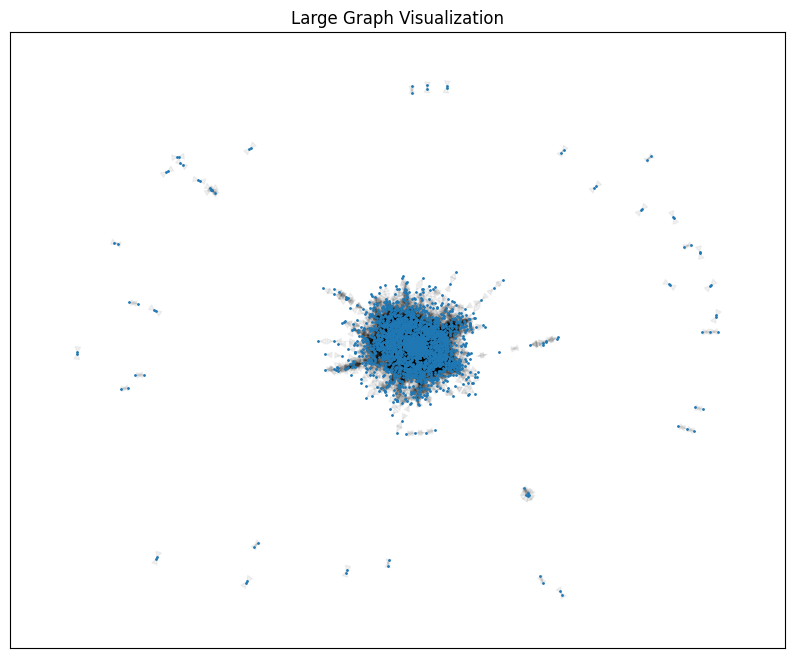


----
The accuracy has changed by -0.0010
Change in edges:  16434.0  | Percentage change: 311.37%


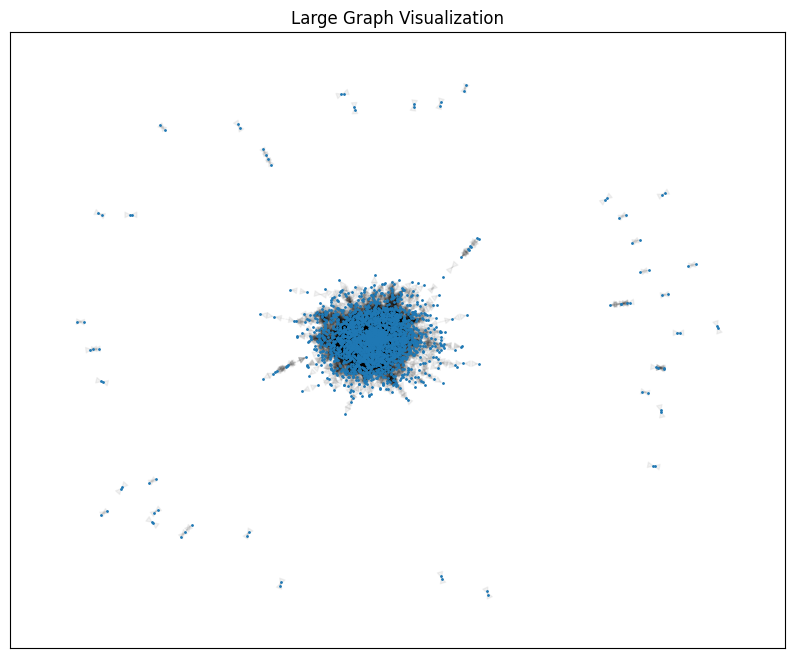

In [131]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

print_graph(G)

# for ptb in ptb_rate:
data = dataset.get_data()[0]
modified_graph = data

init_edges = len(modified_graph.edge_index[1])

G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

budget = len(tuple_list)
# budget = math.floor(ptb * G.number_of_edges() * 1/2)
# print(budget)
# print(len(tuple_list))

random.shuffle(tuple_list)

edges_to_add = tuple_list[:budget]

for i in edges_to_add:
    one = i[0]
    two = i[1]

    if G.has_edge(one, two):
        print('uh oh')
    add_edge(G, one, two, undirected=True)

modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
final_edges = len(modified_graph.edge_index[1])

acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
output_accuracy_change(ground_truth, acc) 
number_added_edges(init_edges, final_edges, is_undirected=True)

print_graph(G)
# print("Number of k-hops considered:", z)

In [137]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)

# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] <= 1):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and check_incorrect_neighborhood(G, i, j, orig_pred, y):
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]])
print(len(tuple_list))

665
16434


In [134]:
16434 / (G.number_of_edges() * 1/2)

3.1136794240242516

In [140]:
ptb_rate = [i * 0.05 for i in range(int(3.15 / 0.05) + 1)]
print(ptb_rate)


# print_graph(G)
results = []
for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)
    
    # budget = len(tuple_list)
    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    # print(budget)
    # print(len(tuple_list))
    
    # random.shuffle(tuple_list)
    
    edges_to_add = tuple_list[:budget]
    
    for i in edges_to_add:
        one = i[0]
        two = i[1]
    
        if G.has_edge(one, two):
            print('uh oh')
        add_edge(G, one, two, undirected=True)
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
    
    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    results.append(abs(acc - ground_truth))

# print_graph(G)
# print("Number of k-hops considered:", z)

[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7000000000000001, 0.75, 0.8, 0.8500000000000001, 0.9, 0.9500000000000001, 1.0, 1.05, 1.1, 1.1500000000000001, 1.2000000000000002, 1.25, 1.3, 1.35, 1.4000000000000001, 1.4500000000000002, 1.5, 1.55, 1.6, 1.6500000000000001, 1.7000000000000002, 1.75, 1.8, 1.85, 1.9000000000000001, 1.9500000000000002, 2.0, 2.0500000000000003, 2.1, 2.15, 2.2, 2.25, 2.3000000000000003, 2.35, 2.4000000000000004, 2.45, 2.5, 2.5500000000000003, 2.6, 2.6500000000000004, 2.7, 2.75, 2.8000000000000003, 2.85, 2.9000000000000004, 2.95, 3.0, 3.0500000000000003, 3.1]

----
The accuracy has not changed.
Change in edges:  0.0  | Percentage change: 0.00%

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%

----
The accuracy has changed by 0.0030
Change in edges:  527.0  | Percentage change: 9.98%

----
The accuracy has changed by 0.0040
Change in

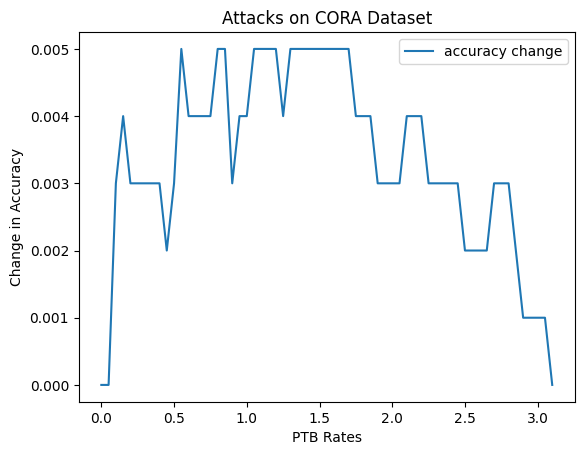

In [143]:
# Plotting
plt.plot(ptb_rate, results, label="accuracy change")

plt.xlabel('PTB Rates')
plt.ylabel('Change in Accuracy')
plt.title('Attacks on CORA Dataset')
plt.legend()

output_path = f"./data/using_incorrect_graph.png"
plt.savefig(output_path)

# Show plot
plt.show()

In [169]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)

# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] <= 0.5):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and check_not_in_neighborhood(G, i, j, y):
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]])
print(len(tuple_list))

665


KeyboardInterrupt: 

In [ ]:
max_b = len(tuple_list) / (G.number_of_edges() * 1/2)

In [ ]:
ptb_rate = [(i+1) * 0.05 for i in range(int(max_b / 0.05) + 1)]
print(ptb_rate)


# print_graph(G)
results = []
for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)
    
    # budget = len(tuple_list)
    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    # print(budget)
    # print(len(tuple_list))
    
    # random.shuffle(tuple_list)
    
    edges_to_add = tuple_list[:budget]
    
    for i in edges_to_add:
        one = i[0]
        two = i[1]
    
        if G.has_edge(one, two):
            print('uh oh')
        add_edge(G, one, two, undirected=True)
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
    
    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    results.append(abs(acc - ground_truth))

# print_graph(G)
# print("Number of k-hops considered:", z)

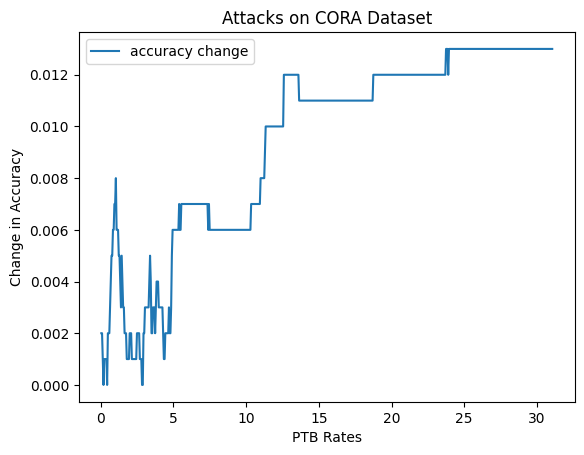

In [164]:
# Plotting
plt.plot(ptb_rate, results, label="accuracy change")

plt.xlabel('PTB Rates')
plt.ylabel('Change in Accuracy')
plt.title('Attacks on CORA Dataset')
plt.legend()

output_path = f"./data/using_incorrect_w_homophily_bound_graph.png"
plt.savefig(output_path)

# Show plot
plt.show()

### all mask

In [180]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)

# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] <= 1):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and check_not_in_neighborhood(G, i, j, y):
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]])
print(len(tuple_list))

665
163784


In [181]:
max_b = len(tuple_list) / (G.number_of_edges() * 1/2)

In [182]:
ptb_rate = [(i+1) * 0.05 for i in range(int(max_b / 0.05) + 1)]

ground_truth_no_mask, orig_pred_no_mask = get_ground_truth(model, data, Models.GCN, testMask=False)

# print_graph(G)
results = []
for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)
    
    # budget = len(tuple_list)
    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    # print(budget)
    # print(len(tuple_list))
    
    # random.shuffle(tuple_list)
    
    edges_to_add = tuple_list[:budget]
    
    for i in edges_to_add:
        one = i[0]
        two = i[1]
    
        if G.has_edge(one, two):
            print('uh oh')
        add_edge(G, one, two, undirected=True)
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
    
    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=False)
    output_accuracy_change(ground_truth_no_mask, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    results.append(abs(acc - ground_truth_no_mask))

# print_graph(G)
# print("Number of k-hops considered:", z)


----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%

----
The accuracy has not changed.
Change in edges:  527.0  | Percentage change: 9.98%

----
The accuracy has changed by -0.0007
Change in edges:  791.0  | Percentage change: 14.99%

----
The accuracy has changed by -0.0011
Change in edges:  1055.0  | Percentage change: 19.99%

----
The accuracy has changed by -0.0011
Change in edges:  1319.0  | Percentage change: 24.99%

----
The accuracy has changed by -0.0011
Change in edges:  1583.0  | Percentage change: 29.99%

----
The accuracy has changed by -0.0018
Change in edges:  1847.0  | Percentage change: 34.99%

----
The accuracy has changed by -0.0018
Change in edges:  2111.0  | Percentage change: 40.00%

----
The accuracy has changed by -0.0011
Change in edges:  2375.0  | Percentage change: 45.00%

----
The accuracy has not changed.
Change in edges:  2639.0  | Percentage change: 50.00%

----
The accuracy has changed by 0.0007
Change in edges:  2902

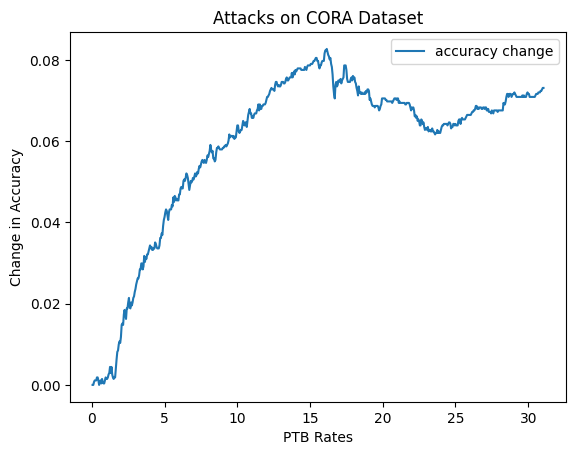

In [183]:
# Plotting
plt.plot(ptb_rate, results, label="accuracy change")

plt.xlabel('PTB Rates')
plt.ylabel('Change in Accuracy')
plt.title('Attacks on CORA Dataset')
plt.legend()

output_path = f"./data/using_incorrect_w_o_test_mask_graph.png"
plt.savefig(output_path)

# Show plot
plt.show()

### checking neighborhood and predictions

In [184]:
data = dataset.get_data()[0]
    
G, x, y, train_mask, test_mask = convert_to_networkx(data)

# get incorrect classification indices
incorrect = torch.nonzero(orig_pred != y).squeeze().tolist()

# sort based on minimum degree
lowest_homophily_nodes = {}
for j in range(0, len(incorrect)):
    if (edge_homo[j] <= 1):
        lowest_homophily_nodes[j] = edge_homo[j]

# lowest_homophily_nodes = dict(sorted(lowest_homophily_nodes.items(), key=lambda x: x[1], reverse=False))
# zero_homophily_nodes = {key: value for key, value in my_dict.items() if value == 0}
print(len(lowest_homophily_nodes))

# put all of these in a set for a budget and select
tuple_list = []
for a in range(0, len(lowest_homophily_nodes)):
    i = list(lowest_homophily_nodes.keys())[a]
    for b in range(a + 1, len(lowest_homophily_nodes)):
        j = list(lowest_homophily_nodes.keys())[b]
        # if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and orig_pred[j] != orig_pred[i]:
        if i != j and not G.has_edge(i, j) and orig_pred[j] != y[i] and check_not_in_neighborhood(G, i, j, y) and check_incorrect_neighborhood(G, i, j, orig_pred, y):
            tuple_list.append((i, j))

# print(tuple_list)
tuple_list = sorted(tuple_list, key=lambda x: edge_homo[x[0]] + edge_homo[x[1]])
print(len(tuple_list))

665
12672


In [185]:
max_b = len(tuple_list) / (G.number_of_edges() * 1/2)

ptb_rate = [(i+1) * 0.05 for i in range(int(max_b / 0.05) + 1)]

ground_truth_no_mask, orig_pred_no_mask = get_ground_truth(model, data, Models.GCN, testMask=False)

# print_graph(G)
results = []
for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)
    
    # budget = len(tuple_list)
    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    # print(budget)
    # print(len(tuple_list))
    
    # random.shuffle(tuple_list)
    
    edges_to_add = tuple_list[:budget]
    
    for i in edges_to_add:
        one = i[0]
        two = i[1]
    
        if G.has_edge(one, two):
            print('uh oh')
        add_edge(G, one, two, undirected=True)
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
    
    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=False)
    output_accuracy_change(ground_truth_no_mask, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    results.append(abs(acc - ground_truth_no_mask))

# print_graph(G)
# print("Number of k-hops considered:", z)


----
The accuracy has changed by 0.0007
Change in edges:  263.0  | Percentage change: 4.98%

----
The accuracy has changed by 0.0030
Change in edges:  527.0  | Percentage change: 9.98%

----
The accuracy has changed by 0.0048
Change in edges:  791.0  | Percentage change: 14.99%

----
The accuracy has changed by 0.0041
Change in edges:  1055.0  | Percentage change: 19.99%

----
The accuracy has changed by 0.0055
Change in edges:  1319.0  | Percentage change: 24.99%

----
The accuracy has changed by 0.0059
Change in edges:  1583.0  | Percentage change: 29.99%

----
The accuracy has changed by 0.0074
Change in edges:  1847.0  | Percentage change: 34.99%

----
The accuracy has changed by 0.0070
Change in edges:  2111.0  | Percentage change: 40.00%

----
The accuracy has changed by 0.0055
Change in edges:  2375.0  | Percentage change: 45.00%

----
The accuracy has changed by 0.0022
Change in edges:  2639.0  | Percentage change: 50.00%

----
The accuracy has changed by 0.0011
Change in edge

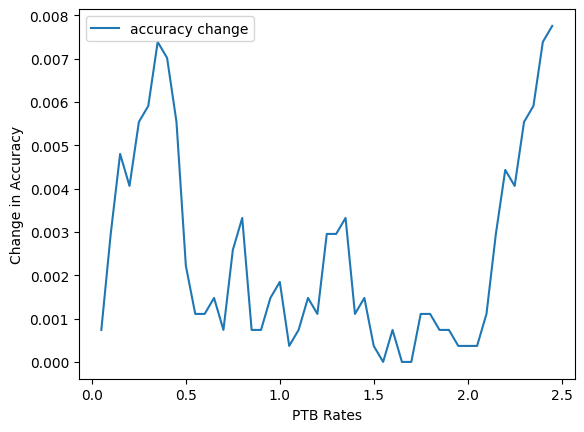

In [186]:
# Plotting
plt.plot(ptb_rate, results, label="accuracy change")

plt.xlabel('PTB Rates')
plt.ylabel('Change in Accuracy')
# plt.title('Attacks on CORA Dataset')
plt.legend()

output_path = f"./data/using_incorrect_w_o_test_mask_graph_considering_neighbor_and_preds.png"
plt.savefig(output_path)

# Show plot
plt.show()

### trying to flip

what do you have to do...you have to find node and get it to flip

In [104]:
data = dataset.get_data()[0]
G, x, y, train_mask, test_mask = convert_to_networkx(data)

centrality = nx.eigenvector_centrality_numpy(G)

sorted_cent = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
sorted_cent = {key: value for key, value in sorted_cent}


cent_set = {label: [] for label in set(data.y.tolist())}
for i in sorted_cent:
    cent_set[y[i].item()].append((i, sorted_cent[i]))

for i in cent_set.keys():
    cent_set[i] = sorted(cent_set[i], key=lambda x: x[1], reverse=False)

print(cent_set)

{0: [(3, -3.171019859074173e-18), (2544, -2.829423415544959e-18), (1036, -2.0982150908387146e-18), (2639, -1.6736047582619231e-18), (292, -1.4423026832285238e-18), (917, 1.9458417989531298e-19), (2562, 3.178282503056892e-19), (260, 1.7574200494992622e-11), (365, 2.529090032157895e-10), (1556, 2.718020273470622e-10), (2469, 3.6220201261121012e-09), (2470, 3.8925954124245685e-09), (888, 3.9114824613594374e-09), (614, 4.1467375580835015e-09), (1475, 5.187130902566418e-08), (1391, 5.692199620213302e-08), (1078, 6.691855155588165e-08), (2449, 1.3306029920882054e-07), (730, 1.5711112886267756e-07), (1188, 1.9441240453829006e-07), (2171, 2.0115274751962606e-07), (2408, 4.145382773537061e-07), (475, 4.696674432327481e-07), (1524, 4.806688813198416e-07), (975, 5.558262579919715e-07), (2098, 5.558262579922285e-07), (2342, 5.678975564538667e-07), (1672, 6.591103917923456e-07), (642, 7.272988077103599e-07), (2702, 7.290284880729892e-07), (1693, 8.191601467395406e-07), (62, 8.643387971308768e-07), 

In [109]:
ptb_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5, 1]
# ptb_rate = [0.05]

# print_graph(G)

for ptb in ptb_rate:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    # budget = 1000
    # print(budget)
    # print(len(tuple_list))

    count = 0
    for i in range(budget):
        ind = list(sorted_cent.keys())[i]
        for j in range(i + 1, budget):
            ind2 = list(sorted_cent.keys())[j]
            if (y[ind].item() != y[ind2].item()):
                add_edge(G, ind, ind2, undirected=True)
                count += 1
            if count == budget:
                break
        if count == budget:
            break
        
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    acc, pred = test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)
    output_accuracy_change(ground_truth, acc) 
    number_added_edges(init_edges, final_edges, is_undirected=True)

    # print_graph(modified_graph)
    # print("Number of k-hops considered:", z)


----
The accuracy has changed by 0.0010
Change in edges:  231.0  | Percentage change: 4.38%

----
The accuracy has changed by -0.0020
Change in edges:  513.0  | Percentage change: 9.72%

----
The accuracy has changed by -0.0060
Change in edges:  777.0  | Percentage change: 14.72%

----
The accuracy has changed by -0.0020
Change in edges:  1041.0  | Percentage change: 19.72%

----
The accuracy has changed by 0.0040
Change in edges:  1305.0  | Percentage change: 24.73%

----
The accuracy has not changed.
Change in edges:  1569.0  | Percentage change: 29.73%

----
The accuracy has changed by 0.0020
Change in edges:  2625.0  | Percentage change: 49.73%


IndexError: list index out of range